# ⌨️ Level 2 - Project 5: Autocomplete and Autocorrect Analytics

**Domain:** Natural Language Processing (NLP) & Text Analytics  
**Internship Track:** Data Analytics Internship (Oasis Infobyte)  
**Author:** Akshay Anil Kumar  

---

## 1. Text Preprocessing & Vocabulary Ingestion
We load a text corpus, clean it by converting it to lowercase, strip punctuation anomalies, tokenize it into individual words, and construct a word frequency dictionary.


In [6]:
import os  # Added this to fix the NameError!
import re
import collections
import matplotlib.pyplot as plt
import seaborn as sns

# Create a sample text file programmatically if one isn't present
text_file = "sample_text.txt"
if not os.path.exists(text_file):
    sample_corpus = """
    data analytics is the science of analyzing raw data to make conclusions. 
    data science and machine learning are shifting industrial paradigms. 
    python is a powerful programming language for data engineering.
    machine learning algorithms help build smart predictive applications.
    analytics tools help business analysts process information.
    """
    with open(text_file, "w") as f:
        f.write(sample_corpus.strip())

# Read and preprocess the words from the text file
with open(text_file, 'r', encoding='utf-8') as f:
    text = f.read().lower()

# Isolate all clean words using Regular Expressions
words = re.findall(r'\w+', text)
word_counts = collections.Counter(words)
total_words = sum(word_counts.values())

# Calculate individual probabilities for each word
word_probabilities = {word: count / total_words for word, count in word_counts.items()}

print("=== NLP Corpus Summary ===")
print(f"Total tokens extracted: {total_words}")
print(f"Unique vocabulary size: {len(word_counts)}")
print("\nTop 5 most frequent words:", word_counts.most_common(5))

=== NLP Corpus Summary ===
Total tokens extracted: 45
Unique vocabulary size: 36

Top 5 most frequent words: [('data', 4), ('analytics', 2), ('is', 2), ('science', 2), ('machine', 2)]


## 2. Autocorrect Engine Development
To fix typos, we implement a sequence generator that alters a misspelled input string by trying four classic operations: **Deletions** (skipping a letter), **Transpositions** (swapping adjacent letters), **Replacements** (changing a letter), and **Insertions** (adding a letter). It then outputs the variation with the highest probability from our text dataset vocabulary.

In [7]:
def get_edits(word):
    """Generates all possible edits that are 1 letter away from the input word."""
    letters    = 'abcdefghijklmnopqrstuvwxyz'
    splits     = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    deletes    = [L + R[1:] for L, R in splits if R]
    transposes = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R)>1]
    replaces   = [L + c + R[1:] for L, R in splits if R for c in letters]
    inserts    = [L + c + R for L, R in splits for c in letters]
    return set(deletes + transposes + replaces + inserts)

def autocorrect(word):
    """Finds the best matching word variant present in our vocabulary."""
    word = word.lower()
    if word in word_counts:
        return [word]
    
    # Generate potential candidate edits
    candidates = get_edits(word)
    valid_candidates = [w for w in candidates if w in word_counts]
    
    # Sort candidates based on how frequently they appear in our text corpus
    best_guesses = sorted(valid_candidates, key=lambda w: word_probabilities[w], reverse=True)
    return best_guesses[:3] if best_guesses else [word]

# Quick live verification test of our autocorrect feature
typo = "datta"
print(f"Typo Entered: '{typo}' -> Autocorrect Suggestions:", autocorrect(typo))
typo2 = "machne"
print(f"Typo Entered: '{typo2}' -> Autocorrect Suggestions:", autocorrect(typo2))

Typo Entered: 'datta' -> Autocorrect Suggestions: ['data']
Typo Entered: 'machne' -> Autocorrect Suggestions: ['machine']


## 3. Autocomplete Search Analytics
We write a query matching lookup tool that looks at a starting prefix typed by a user, scans our data vocabulary matrix, and returns the top phrases sorting them by historical popularity.

User types prefix: 'da' -> Autocomplete Predictions: ['data']


C:\Users\Akshayanu\AppData\Local\Temp\ipykernel_26552\1033135197.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_10.values()), y=list(top_10.keys()), palette="Blues_r")


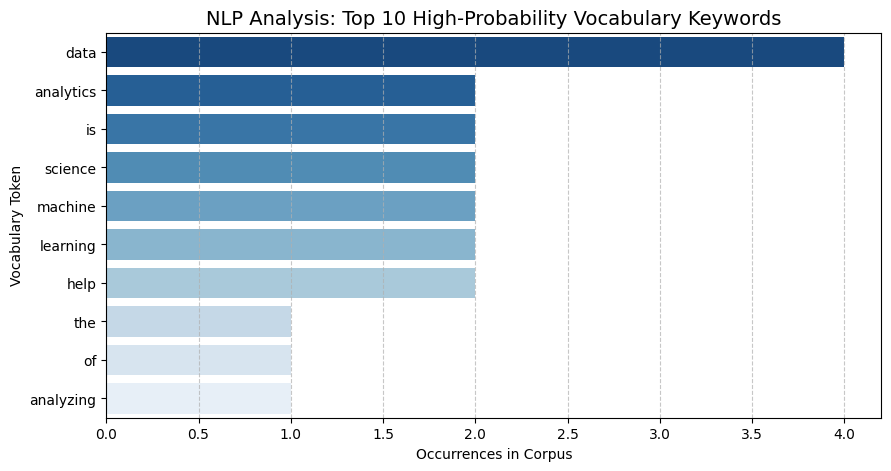

In [8]:
def autocomplete(prefix):
    """Finds words that start with the user's typed prefix, sorted by probability."""
    prefix = prefix.lower()
    matches = [word for word in word_counts if word.startswith(prefix)]
    best_matches = sorted(matches, key=lambda w: word_probabilities[w], reverse=True)
    return best_matches[:5]

# Analyze top prefix trends
search_prefix = "da"
print(f"User types prefix: '{search_prefix}' -> Autocomplete Predictions:", autocomplete(search_prefix))

# Plot the top 10 words in our vocabulary to show search popularity trends
top_10 = dict(word_counts.most_common(10))
plt.figure(figsize=(10, 5))
sns.barplot(x=list(top_10.values()), y=list(top_10.keys()), palette="Blues_r")
plt.title("NLP Analysis: Top 10 High-Probability Vocabulary Keywords", fontsize=14)
plt.xlabel("Occurrences in Corpus")
plt.ylabel("Vocabulary Token")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()